### Imports ###

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import optuna

In [2]:
from indoor_plant_preprocessing import data_preparation
data, data_optimal = data_preparation()
data, data_optimal

(                   Plant_ID  Room_Temperature_C  Humidity_%  Soil_Moisture_%  \
 0    Sansevieria cylindrica                21.7        77.5             51.9   
 1                 Aloe vera                22.6        68.9             28.2   
 2              Ficus lyrata                17.2        44.3             13.6   
 3        Monstera deliciosa                25.0        72.2             38.4   
 4              Ficus lyrata                23.2        51.6             37.9   
 ..                      ...                 ...         ...              ...   
 995  Sansevieria cylindrica                32.4        58.0             31.7   
 996   Schefflera arboricola                24.3        39.4             32.9   
 997      Monstera deliciosa                26.4        52.4             58.5   
 998       Epipremnum aureum                18.7        60.1             24.8   
 999  Sansevieria cylindrica                28.5        46.4             41.4   
 
      Optimal_Room_Tempera

### Clustering Ward's Method ###

In [3]:
optimal_features = [
    "Optimal_Room_Temperature_C",
    "Optimal_Humidity_%",
    "Optimal_Soil_Moisture_%",
    "Optimal_Light_Intensity_Lux"
]

scaler_optimal = StandardScaler()
data_optimal_scaled = data_optimal.copy()

optimal_X_scaled = pd.DataFrame(
    scaler_optimal.fit_transform(data_optimal_scaled[optimal_features]),
    columns=optimal_features,
    index=data_optimal_scaled.index
)

optimal_X_scaled

,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux
0,0.356034,0.210183,0.291077,-0.818911
1,0.356034,-1.700568,-1.763585,1.716416
2,1.542816,1.356633,0.975964,0.702286
3,-0.830747,0.592333,0.633521,0.195220
4,0.356034,1.356633,1.318408,-1.072443
5,-2.017529,-0.171968,-0.051367,-0.311845
6,1.542816,0.210183,0.291077,1.969949
7,0.356034,0.592333,0.633521,-0.058313
8,-0.830747,-1.318418,-1.421141,0.955818
9,0.356034,0.210183,0.291077,-0.565378


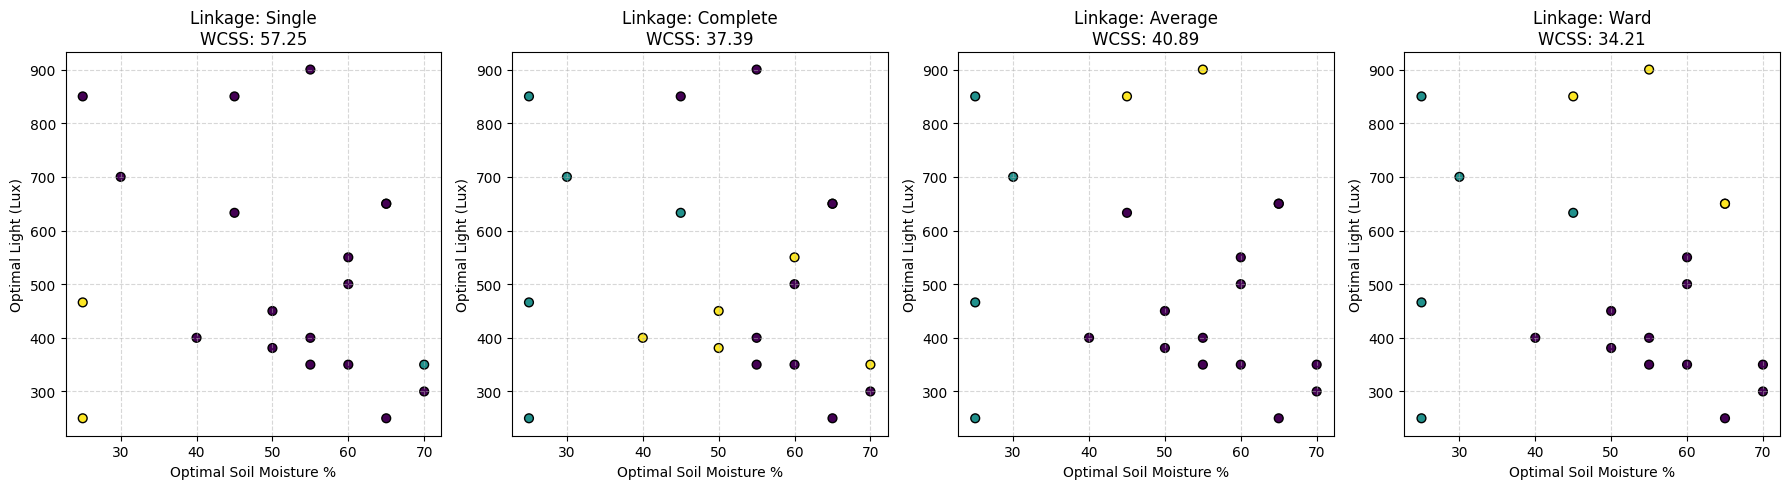

In [4]:
from sklearn.cluster import AgglomerativeClustering

# Different linkage methods (measure of distance between clusters)
methods = ['single', 'complete', 'average', 'ward']
plt.figure(figsize=(18, 5))
for i, link in enumerate(methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = model.fit_predict(optimal_X_scaled)
    # WCSS (within cluster sum of squares)
    wcss = 0
    for cluster_id in range(3):
        cluster_points = optimal_X_scaled[labels == cluster_id]
        centroid = cluster_points.mean(axis=0)
        wcss += np.sum((cluster_points - centroid) ** 2)

    plt.subplot(1, 4, i + 1)
    plt.scatter(data_optimal["Optimal_Soil_Moisture_%"], data_optimal["Optimal_Light_Intensity_Lux"], c=labels, cmap='viridis', s=40, edgecolors='k')
    plt.title(f"Linkage: {link.capitalize()}\nWCSS: {wcss:.2f}")
    plt.xlabel("Optimal Soil Moisture %")
    plt.ylabel("Optimal Light (Lux)")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

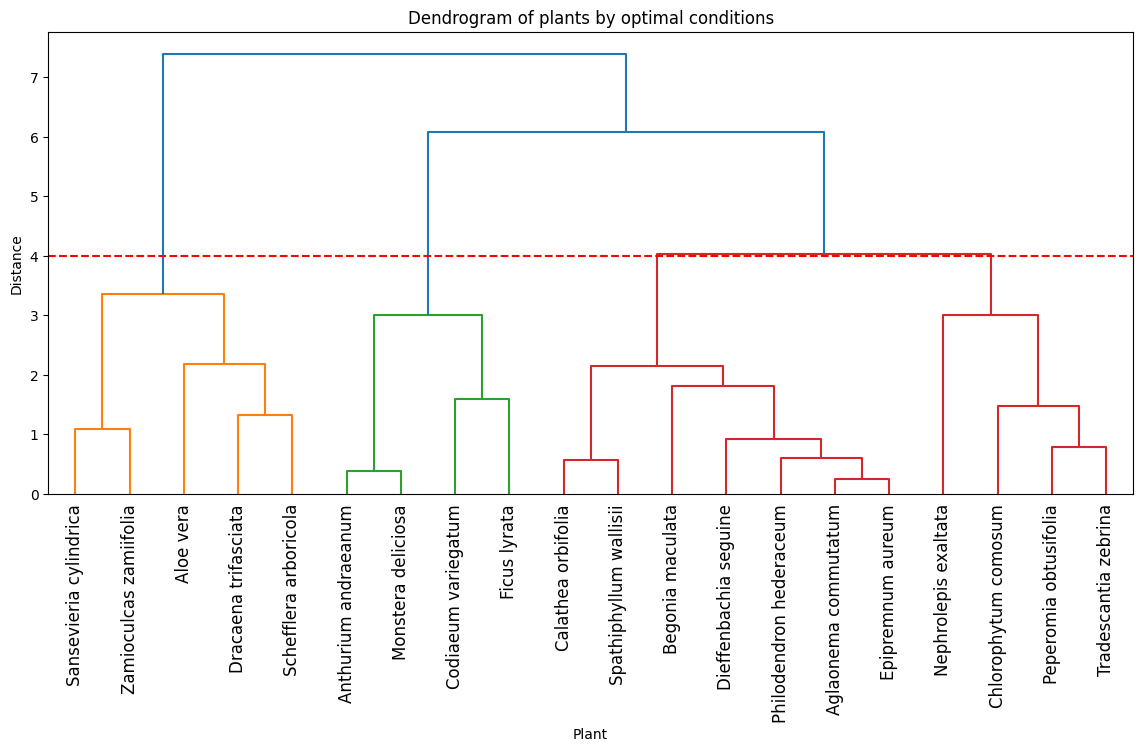

In [5]:
# Ward's method
Z = linkage(optimal_X_scaled, method='ward')
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=data_optimal['Plant_ID'].values, leaf_rotation=90)
plt.axhline(y=4, color='r', linestyle='--')
plt.title("Dendrogram of plants by optimal conditions")
plt.xlabel("Plant")
plt.ylabel("Distance")
plt.show()

In [6]:
K = 3
model = AgglomerativeClustering(n_clusters=K, linkage='ward').fit(optimal_X_scaled)
data_optimal['care_group'] = model.labels_

# Profile each cluster
profile = data_optimal.groupby('care_group')[optimal_features].mean().round(1)
profile['n_plants'] = data_optimal.groupby('care_group').size()
profile

,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux,n_plants
care_group,,,,,
0,23.4,63.2,57.7,389.2,11
1,23.6,39.0,30.0,579.8,5
2,24.8,63.8,57.5,762.5,4


In [8]:
# Plants per group
for g in sorted(data_optimal['care_group'].unique()):
    plants = data_optimal[data_optimal['care_group'] == g]['Plant_ID'].tolist()
    print(f"Group {g} ({len(plants)} plants): {plants}")

Group 0 (11 plants): ['Aglaonema commutatum', 'Begonia maculata', 'Calathea orbifolia', 'Chlorophytum comosum', 'Dieffenbachia seguine', 'Epipremnum aureum', 'Nephrolepis exaltata', 'Peperomia obtusifolia', 'Philodendron hederaceum', 'Spathiphyllum wallisii', 'Tradescantia zebrina']
Group 1 (5 plants): ['Aloe vera', 'Dracaena trifasciata', 'Sansevieria cylindrica', 'Schefflera arboricola', 'Zamioculcas zamiifolia']
Group 2 (4 plants): ['Anthurium andraeanum', 'Codiaeum variegatum', 'Ficus lyrata', 'Monstera deliciosa']


In [9]:
# Human-readable labels based on the profiles
group_labels = {
    0: "Cool-temperate moderate",  # cooler, moderate everything
    1: "Succulent / dry-loving",   # warm, dry air, dry soil, bright
    2: "Shade-tolerant tropical",  # warm, humid, low light
}
profile['label'] = profile.index.map(group_labels)
profile[['n_plants', 'label']]

,n_plants,label
care_group,,
0,11,Cool-temperate moderate
1,5,Succulent / dry-loving
2,4,Shade-tolerant tropical


### Feature Engineering for Classification ###

In [10]:
# Bring the cluster label from data_optimal into the main data
data = data.merge(
    data_optimal[['Plant_ID', 'care_group']],
    on='Plant_ID',
    how='left'
)

# Drop optimal columns and Plant_ID (so the model can't cheat)
data_model = data.drop(columns=["Optimal_Humidity_%", "Optimal_Room_Temperature_C",
                                "Optimal_Soil_Moisture_%", "Optimal_Light_Intensity_Lux",
                                "Plant_ID"])
data_model

,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light_Intensity,Pump_time,soil_deficit,temp_deviation,air_hum_deficit,light_deviation,et_approx,care_group
0,21.7,77.5,51.9,802,20.5,-26.9,-2.3,-42.5,336,221.699363,1
1,22.6,68.9,28.2,970,19.1,-3.2,-1.4,-33.9,120,313.619456,1
2,17.2,44.3,13.6,306,47.7,31.4,-6.8,5.7,-544,116.185430,2
3,25.0,72.2,38.4,121,20.7,26.6,0.0,-2.2,-529,41.325137,2
4,23.2,51.6,37.9,520,46.5,7.1,-0.8,-1.6,-330,229.353612,2
...,...,...,...,...,...,...,...,...,...,...,...
995,32.4,58.0,31.7,981,37.0,-6.7,8.4,-23.0,515,538.718644,1
996,24.3,39.4,32.9,957,9.1,12.1,1.3,10.6,324,575.621287,1
997,26.4,52.4,58.5,861,13.4,6.5,1.4,17.6,211,425.662921,2
998,18.7,60.1,24.8,786,44.2,30.2,-5.3,-0.1,386,240.559738,0


In [11]:
X = data_model.drop(columns=["care_group"])
y = data_model["care_group"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features: {list(X.columns)}")
print(f"Class distribution:\n{y.value_counts().sort_index()}")

Features: ['Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Light_Intensity', 'Pump_time', 'soil_deficit', 'temp_deviation', 'air_hum_deficit', 'light_deviation', 'et_approx']
Class distribution:
care_group
0    540
1    263
2    197
Name: count, dtype: int64


In [12]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 50, 500
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 2, 7
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "random_state": 42,
        "n_jobs": -1,
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1,
    )

    train_score = cv_results["train_score"].mean()
    val_score = cv_results["test_score"].mean()
    val_std = cv_results["test_score"].std()

    # Overfitting gap (train - val). Bigger gap = more overfit.
    gap = train_score - val_score

    # Penalty weights — tune these to taste.
    LAMBDA_GAP = 0.5   # how harshly to punish the train/val gap
    LAMBDA_STD = 0.1   # how harshly to punish unstable folds

    penalty = LAMBDA_GAP * gap + LAMBDA_STD * val_std

    # Log for inspection
    trial.set_user_attr("train_score", train_score)
    trial.set_user_attr("val_score", val_score)
    trial.set_user_attr("gap", gap)
    trial.set_user_attr("val_std", val_std)

    return val_score - penalty

In [13]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-05-18 08:27:45,155] A new study created in memory with name: no-name-78f7a723-1d52-4149-9ca8-8df2eabc73dd


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-18 08:27:49,899] Trial 0 finished with value: 0.7836458458835525 and parameters: {'n_estimators': 485, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': None}. Best is trial 0 with value: 0.7836458458835525.
[I 2026-05-18 08:27:52,531] Trial 1 finished with value: 0.7053646666680002 and parameters: {'n_estimators': 226, 'max_depth': 4, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7836458458835525.
[I 2026-05-18 08:27:55,193] Trial 2 finished with value: 0.7055275767042593 and parameters: {'n_estimators': 245, 'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7836458458835525.
[I 2026-05-18 08:27:56,999] Trial 3 finished with value: 0.686852701465352 and parameters: {'n_estimators': 137, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.7836458458835525.

In [14]:
print("Best parameters:")
print(study.best_params)

print(f"\nBest CV accuracy: {study.best_value:.3f}")

Best parameters:
{'n_estimators': 181, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': None}

Best CV accuracy: 0.812


In [15]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42
)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",181
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",6
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [16]:
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Train accuracy: 0.949
Test accuracy:  0.890


In [17]:
# Per-group classification report
preds = best_rf.predict(X_test)
print(classification_report(y_test, preds, digits=3))

              precision    recall  f1-score   support

           0      0.917     0.926     0.922       108
           1      0.868     0.868     0.868        53
           2      0.842     0.821     0.831        39

    accuracy                          0.890       200
   macro avg      0.876     0.871     0.874       200
weighted avg      0.890     0.890     0.890       200



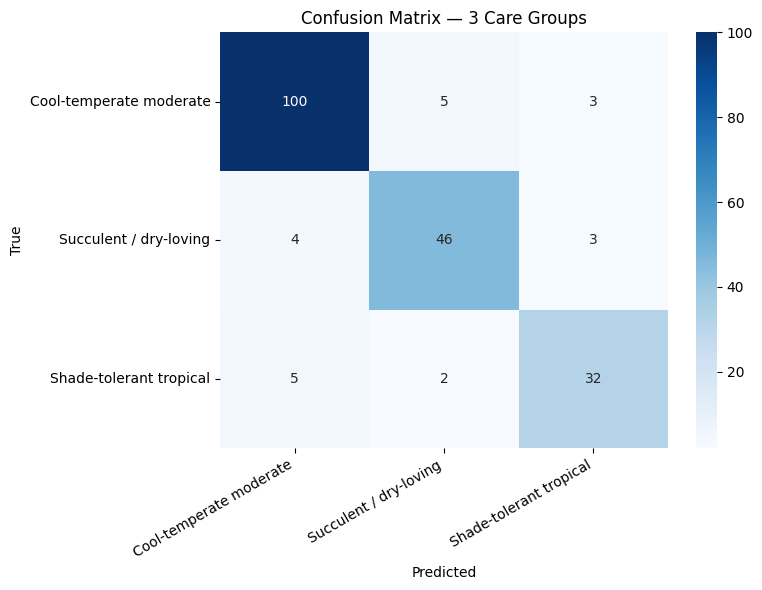

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, preds)
group_names = [group_labels[g] for g in sorted(group_labels.keys())]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=group_names, yticklabels=group_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {K} Care Groups')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

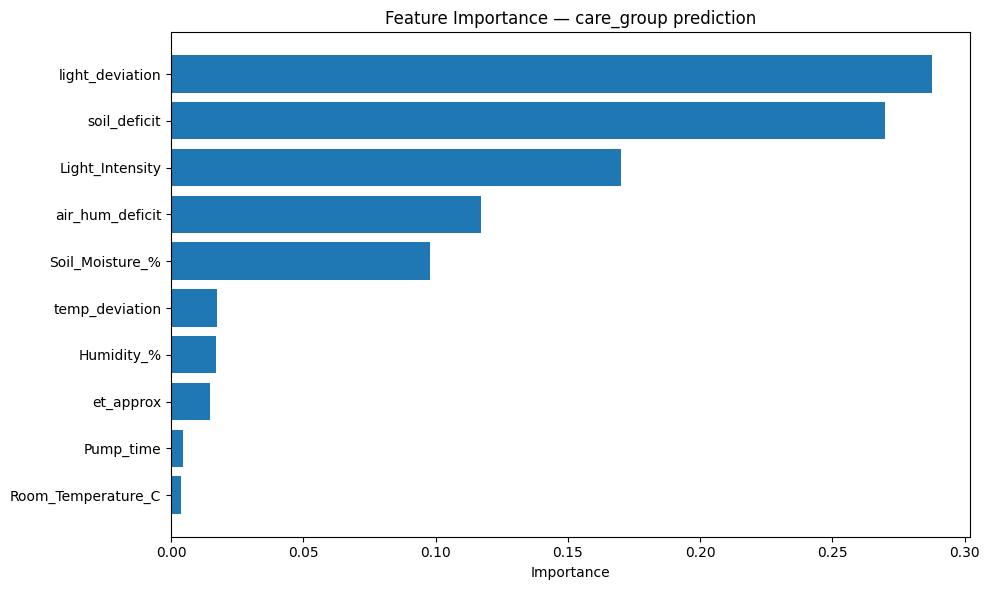

,Feature,Importance
8,light_deviation,0.287798
5,soil_deficit,0.270028
3,Light_Intensity,0.170066
7,air_hum_deficit,0.117068
2,Soil_Moisture_%,0.098066
6,temp_deviation,0.017338
1,Humidity_%,0.016896
9,et_approx,0.014597
4,Pump_time,0.004464
0,Room_Temperature_C,0.003680


In [19]:
# Feature importance
fi = pd.DataFrame({"Feature": X.columns, "Importance": best_rf.feature_importances_})
fi = fi.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fi["Feature"], fi["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance — care_group prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

fi